<a href="https://colab.research.google.com/github/SaanchitaV/RagAllied-SARAGA-Dataset/blob/main/RagAllied.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing the mirdata, compiam and pandas libraries

*   ***mirdata*** - a general library for MIR (music information retrieval) datasets, though It's not Indian-music-specific; it's a standardized loader for dozens of research datasets (Saraga among them). It's whole job is to handle the annoying parts: downloading the data, validating if it's complete and uncorrupted (checksums), and giving a uniform Python interface to access raga, artist, pitch tracks, tonic, etc. as object attributes instead of parsing raw files and folder structures yourself. It exists because every MIR dataset ships its annotations in its own messy format, and mirdata normalizes that. For your census, mirdata is what loads Saraga and exposes the metadata fields.

*   ***compiam*** -  Computational Indian Art Music. This one is domain-specific, built by the MTG/CompMusic group (Serra's lab in Barcelona—the same people who made Saraga). It's a toolkit of methods for Carnatic and Hindustani music: tonic identification, predominant-melody/pitch extraction, raga recognition, rhythm/sama analysis, and it bundles access to the relevant datasets. Where mirdata gives you the data, compiam gives you the analysis tools tuned for this music specifically—including baseline implementations you'll want to compare against (e.g. their tonic-identification methods, which matter for your normalization step)



In [2]:
!pip install mirdata compiam pandas

Saraga Census
=============================================================
Purpose: audit the Saraga Carnatic dataset BEFORE any modeling, so you know
exactly what raga / artist / annotation depth you actually have. Every design
decision downstream (full learned retrieval vs. transition-vector floor,
first- vs second-order transitions, which allied pairs are evaluable) is
decided by the numbers this produces.

Run this in Google Colab (the dataset download is large and needs network).

PASS 1  -> raga inventory + per-raga recording/artist counts   (no pair list needed)
PASS 2  -> allied-pair depth overlay                           (fill in AFTER pass 1)

Author scaffold: structured for Saanchita's swara-retrieval / allied-raga IR project.

In [1]:
!pip install -q kagglehub

---


Downloading dataset directly from Kaggle to - /root/.cache/kagglehub/datasets

---

In [3]:
import kagglehub

path = kagglehub.dataset_download("desolationofsmaug/saraga-carnatic-music-dataset")
print("Path to dataset files:", path)

Resuming download from 0 bytes (4074375909 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/desolationofsmaug/saraga-carnatic-music-dataset/1.archive (0/4074375909) bytes left.


100%|██████████| 3.79G/3.79G [03:01<00:00, 22.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/desolationofsmaug/saraga-carnatic-music-dataset/versions/1




---
Checking how data is stored inside
the dataset - folder structure


---



In [4]:
import os

for root, dirs, files in os.walk(path):
    depth = root[len(path):].count(os.sep)
    if depth <= 2:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:5]:
            print(f"{indent}  {f}")
        if len(files) > 5:
            print(f"{indent}  ... (+{len(files)-5} more files)")

1/
  carnatic/
    96/
      Modhumudi Sudhakar - Paraloka Bhaya.json
      Modhumudi Sudhakar - Paraloka Bhaya.mp3
      Modhumudi Sudhakar - Paraloka Bhaya.pitch.txt
      Modhumudi Sudhakar - Paraloka Bhaya.ctonic.txt
    135/
      Sumithra Vasudev - Sri Guru Na Palitosmi.ctonic.txt
      Sumithra Vasudev - Sri Guru Na Palitosmi.mphrases-manual.txt
      Sumithra Vasudev - Sri Guru Na Palitosmi.sama-manual.txt
      Sumithra Vasudev - Sri Guru Na Palitosmi.mp3
      Sumithra Vasudev - Sri Guru Na Palitosmi.pitch.txt
      ... (+6 more files)
    84/
      Akkarai Sisters - Apparama Bhakti.sections-manual.txt
      Akkarai Sisters - Apparama Bhakti.ctonic.txt
      Akkarai Sisters - Apparama Bhakti.mp3
      Akkarai Sisters - Apparama Bhakti.sama-manual.txt
      Akkarai Sisters - Apparama Bhakti.json
      ... (+5 more files)
    0/
      Cherthala Ranganatha Sharma - Varashiki Vahana.pitch.txt
      Cherthala Ranganatha Sharma - Varashiki Vahana.mp3
      Cherthala Ranganatha Shar

In [5]:
import json, os, glob

# find all json metadata files under the dataset
json_files = glob.glob(os.path.join(path, "**", "*.json"), recursive=True)
print(f"Found {len(json_files)} JSON metadata files\n")

# print the full content of one
with open(json_files[0]) as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2)[:2500])

Found 197 JSON metadata files

{
  "raaga": [
    {
      "uuid": "9e9d8820-ecc5-44b3-8131-60dbd40a0436",
      "name": "Mand\u0101ri"
    }
  ],
  "form": [
    {
      "name": "Kriti"
    }
  ],
  "title": "Paraloka Bhaya",
  "work": [
    {
      "mbid": "8d58f207-c8e4-4e31-b1a7-75c579256619",
      "title": "Paraloka Bhayamu"
    }
  ],
  "length": 471849,
  "taala": [
    {
      "uuid": "c788c38a-b53a-48cb-b7bf-d11769260c4d",
      "name": "\u0100di"
    }
  ],
  "album_artists": [
    {
      "mbid": "571b556c-5b54-48bf-84e3-2bbf6b5c872f",
      "name": "Modhumudi Sudhakar"
    }
  ],
  "mbid": "228802ab-0055-47bf-bc3e-ecdb91fd889c",
  "artists": [
    {
      "instrument": {
        "mbid": "089f123c-0f7d-4105-a64e-49de81ca8fa4",
        "name": "Violin"
      },
      "attributes": "",
      "lead": false,
      "artist": {
        "mbid": "1e85eddd-29cf-4b72-8754-cd37c6fe837f",
        "name": "Palaparti Nageswara Rao"
      }
    },
    {
      "instrument": {
        "mbid"

In [ ]:
import glob, os

# what did kagglehub actually return?
print("path variable:", path if 'path' in dir() else "NOT DEFINED")

# does the hardcoded path exist?
dp = "/kaggle/input/saraga-carnatic-music-dataset"
print("hardcoded exists?", os.path.exists(dp))

# find json files from BOTH candidate roots
for root in [path if 'path' in dir() else None, dp]:
    if root and os.path.exists(root):
        n = len(glob.glob(os.path.join(root, "**", "*.json"), recursive=True))
        print(f"  {root} -> {n} json files")

In [6]:
"""
Saraga Census -- Kaggle-mirror version
=============================================================
Reads Saraga Carnatic directly from the Kaggle dataset
(desolationofsmaug/saraga-carnatic-music-dataset), parsing the per-recording
.json metadata files. No mirdata dependency.

Run AFTER:
    import kagglehub
    path = kagglehub.dataset_download("desolationofsmaug/saraga-carnatic-music-dataset")

Then set DATA_PATH = path (or paste the printed path).

PASS 1 -> raga inventory + per-raga recording/artist counts  (no pair list needed)
PASS 2 -> allied-pair depth overlay                          (fill in AFTER pass 1)
-------------------------------------------------------------
"""

import os
import re
import json
import glob
import unicodedata
from collections import defaultdict

import pandas as pd


# =============================================================
# CONFIG  -- set DATA_PATH to the kagglehub path
# =============================================================
# DATA_PATH = None  # e.g. "/root/.cache/kagglehub/datasets/desolationofsmaug/..."
DATA_PATH = path
OUT_DIR = "/content/census_out"
os.makedirs(OUT_DIR, exist_ok=True)


# =============================================================
# NORMALIZATION
# =============================================================
def normalize_name(s):
    """Strip diacritics so 'Ṣanmukhapriya' == 'Shanmukhapriya'-ish.
    We fold to ASCII and lowercase for grouping, but keep a display version."""
    if not s:
        return "UNKNOWN"
    # NFKD decomposition drops combining marks
    decomposed = unicodedata.normalize("NFKD", s)
    ascii_form = decomposed.encode("ascii", "ignore").decode("ascii")
    ascii_form = ascii_form.strip()
    return ascii_form if ascii_form else s.strip()


def raga_key(name):
    """Grouping key: normalized + lowercased + spaces collapsed."""
    n = normalize_name(name).lower()
    n = re.sub(r"\s+", " ", n).strip()
    return n


# =============================================================
# PARSE ONE RECORDING
# =============================================================
def parse_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    # --- raga ---
    raga_disp = "UNKNOWN"
    raaga = meta.get("raaga") or meta.get("raga")
    if isinstance(raaga, list) and raaga:
        raga_disp = normalize_name(raaga[0].get("name"))
    elif isinstance(raaga, dict):
        raga_disp = normalize_name(raaga.get("name"))

    # --- lead artist: prefer the artist flagged lead==True in `artists`,
    #     fall back to album_artists ---
    lead_artist = None
    artists = meta.get("artists") or []
    for a in artists:
        if a.get("lead") and a.get("artist", {}).get("name"):
            lead_artist = a["artist"]["name"]
            break
    if not lead_artist:
        alb = meta.get("album_artists") or []
        if isinstance(alb, list) and alb:
            lead_artist = alb[0].get("name")
    lead_artist = normalize_name(lead_artist) if lead_artist else "UNKNOWN"

    # --- lead instrument / voice type (useful later, cheap to grab now) ---
    lead_instrument = "UNKNOWN"
    for a in artists:
        if a.get("lead"):
            lead_instrument = (a.get("instrument") or {}).get("name", "UNKNOWN")
            break

    # --- concert / form / taala ---
    def first_name(field):
        v = meta.get(field)
        if isinstance(v, list) and v:
            return normalize_name(v[0].get("name") or v[0].get("title"))
        if isinstance(v, dict):
            return normalize_name(v.get("name") or v.get("title"))
        return "UNKNOWN"

    concert = first_name("concert")
    form = first_name("form")
    taala = first_name("taala")

    # --- annotation coverage: check sibling files in the same folder ---
    folder = os.path.dirname(json_path)
    stem = os.path.splitext(os.path.basename(json_path))[0]
    siblings = os.listdir(folder)
    def has(suffix):
        return any(fn.startswith(stem) and fn.endswith(suffix) for fn in siblings)

    return {
        "track_id": os.path.relpath(folder, DATA_PATH),
        "title": meta.get("title", "UNKNOWN"),
        "raga": raga_disp,
        "raga_key": raga_key(raga_disp),
        "artist": lead_artist,
        "lead_instrument": lead_instrument,
        "concert": concert,
        "form": form,
        "taala": taala,
        "has_tonic": has(".ctonic.txt"),
        "has_pitch": has(".pitch.txt"),
        "has_pitch_vocal": has(".pitch-vocal.txt"),
        "has_phrases": has(".mphrases-manual.txt"),
        "has_sections": has(".sections-manual.txt"),
        "has_mp3": has(".mp3"),
    }


def build_metadata_table():
    assert DATA_PATH, "Set DATA_PATH to the kagglehub download path first."
    json_files = glob.glob(os.path.join(DATA_PATH, "**", "*.json"), recursive=True)
    print(f"Found {len(json_files)} JSON metadata files.")
    rows = []
    for jp in json_files:
        try:
            rows.append(parse_json(jp))
        except Exception as e:
            print(f"  [skip] {jp}: {e}")
    df = pd.DataFrame(rows)
    return df


# =============================================================
# PASS 1  --  RAGA INVENTORY
# =============================================================
def pass1_inventory(df):
    print("\n" + "=" * 60)
    print("PASS 1 : RAGA INVENTORY")
    print("=" * 60)
    print(f"Total recordings: {len(df)}")
    print(f"Distinct ragas:   {df['raga_key'].nunique()}")
    print(f"Distinct artists: {df['artist'].nunique()}")
    print(f"Distinct concerts:{df['concert'].nunique()}")

    per_raga = (
        df.groupby("raga_key")
          .agg(display_name=("raga", "first"),
               recordings=("track_id", "count"),
               artists=("artist", "nunique"),
               concerts=("concert", "nunique"))
          .sort_values("recordings", ascending=False)
    )

    print("\n--- Per-raga depth (all ragas) ---")
    with pd.option_context("display.max_rows", None):
        print(per_raga[["display_name", "recordings", "artists", "concerts"]])

    print("\n--- Annotation coverage ---")
    for col in ["has_tonic", "has_pitch", "has_pitch_vocal",
                "has_phrases", "has_sections", "has_mp3"]:
        print(f"  {col:18s}: {df[col].mean():.1%}")

    learnable = per_raga[(per_raga["artists"] >= 2) & (per_raga["recordings"] >= 3)]
    print(f"\nRagas with >=2 artists & >=3 recordings (learned-path eligible): "
          f"{len(learnable)} of {len(per_raga)}")
    print("\nLearned-eligible ragas:")
    print(learnable[["display_name", "recordings", "artists"]].to_string())

    per_raga.to_csv(os.path.join(OUT_DIR, "per_raga_depth.csv"))
    df.to_csv(os.path.join(OUT_DIR, "recordings_metadata.csv"), index=False)
    print(f"\nSaved: per_raga_depth.csv  and  recordings_metadata.csv")
    print(">>> Use per_raga_depth.csv as your MENU to build the allied-pair list. <<<")
    return per_raga


# =============================================================
# PASS 2  --  ALLIED-PAIR DEPTH  (fill in AFTER pass 1)
# =============================================================
# Use the raga_key spelling (normalized, lowercase) as it appears in
# per_raga_depth.csv's index. Group by why the pair is hard.
ALLIED_PAIRS = [
    # ("bilahari", "sankarabharanam", "scale_identical"),
    # ("saveri",   "gaula",           "same_janaka"),
]


def pass2_allied_pairs(per_raga):
    if not ALLIED_PAIRS:
        print("\n[PASS 2 skipped] ALLIED_PAIRS empty. Fill from per_raga_depth.csv, re-run.")
        return None

    print("\n" + "=" * 60)
    print("PASS 2 : ALLIED-PAIR DEPTH")
    print("=" * 60)

    def depth(rk):
        if rk in per_raga.index:
            r = per_raga.loc[rk]
            return int(r["recordings"]), int(r["artists"])
        return 0, 0

    rows = []
    for a, b, cat in ALLIED_PAIRS:
        ar, aa = depth(a); br, ba = depth(b)
        min_recs, min_art = min(ar, br), min(aa, ba)
        if min_recs == 0:
            status = "MISSING (one side absent)"
        elif min_art >= 2 and min_recs >= 3:
            status = "LEARNED-ELIGIBLE"
        elif min_recs >= 1:
            status = "FLOOR-ONLY"
        else:
            status = "UNKNOWN"
        rows.append(dict(raga_A=a, recs_A=ar, artists_A=aa,
                         raga_B=b, recs_B=br, artists_B=ba,
                         category=cat, min_recs=min_recs,
                         min_artists=min_art, status=status))

    pair_df = pd.DataFrame(rows).sort_values(["category", "min_artists"],
                                             ascending=[True, False])
    print(pair_df.to_string(index=False))
    pair_df.to_csv(os.path.join(OUT_DIR, "allied_pair_depth.csv"), index=False)
    print(f"\nSaved: allied_pair_depth.csv")
    print(">>> Decides: full learned stack vs. transition-vector floor. <<<")
    return pair_df


# =============================================================
# MAIN
# =============================================================
def main():
    df = build_metadata_table()
    per_raga = pass1_inventory(df)
    pass2_allied_pairs(per_raga)


if __name__ == "__main__":
    main()

Found 197 JSON metadata files.

PASS 1 : RAGA INVENTORY
Total recordings: 197
Distinct ragas:   97
Distinct artists: 17
Distinct concerts:19

--- Per-raga depth (all ragas) ---
                                    display_name  recordings  artists  \
raga_key                                                                
unknown                                  UNKNOWN          13        9   
ragamalika                            Ragamalika           8        7   
kamas                                      Kamas           7        4   
todi                                        Todi           7        7   
saurastram                            Saurastram           7        5   
behag                                      Behag           5        4   
bhairavi                                Bhairavi           5        4   
sanmukhapriya                      Sanmukhapriya           4        3   
surati                                    Surati           4        4   
mohanam             

In [7]:
"""
Diagnostic: inspect ragamalika + UNKNOWN-raga recordings.

Ragamalika = "garland of ragas" -- a single piece deliberately moving through
MANY ragas. So these recordings are multi-raga by nature; the census collapsed
each to a single raga label, which is wrong/uninformative for them. This script
re-opens their JSONs to show the FULL raaga list per recording.

UNKNOWN = the census found no raaga field. We re-open those to check whether
raga info is hiding in another field (or genuinely absent).

Run AFTER the census, in the same notebook (DATA_PATH already set), OR set it here.
"""

import os
import json
import glob
import unicodedata

import pandas as pd


# reuse DATA_PATH from the census if it's in scope; else set it:
try:
    DATA_PATH
except NameError:
    DATA_PATH = "/kaggle/input/saraga-carnatic-music-dataset"


def norm(s):
    if not s:
        return "UNKNOWN"
    d = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii").strip()
    return d if d else s.strip()


def all_ragas(meta):
    """Return the FULL list of raga names on a recording (not just the first)."""
    raaga = meta.get("raaga") or meta.get("raga") or []
    if isinstance(raaga, dict):
        raaga = [raaga]
    return [norm(r.get("name")) for r in raaga if isinstance(r, dict)]


def lead_artist(meta):
    for a in (meta.get("artists") or []):
        if a.get("lead") and a.get("artist", {}).get("name"):
            return norm(a["artist"]["name"])
    alb = meta.get("album_artists") or []
    return norm(alb[0]["name"]) if alb else "UNKNOWN"


json_files = glob.glob(os.path.join(DATA_PATH, "**", "*.json"), recursive=True)

ragamalika_rows = []
unknown_rows = []

for jp in json_files:
    with open(jp, encoding="utf-8") as f:
        meta = json.load(f)
    ragas = all_ragas(meta)
    title = meta.get("title", "UNKNOWN")
    artist = lead_artist(meta)

    # ragamalika: either labeled 'ragamalika' OR has >1 raga listed
    is_ragamalika = (any(r.lower() == "ragamalika" for r in ragas)
                     or len(ragas) > 1)
    if is_ragamalika:
        ragamalika_rows.append({
            "title": title, "artist": artist,
            "n_ragas": len(ragas),
            "ragas": ", ".join(ragas) if ragas else "(none listed)",
        })

    # unknown: no raga field at all, or empty
    if not ragas:
        # dump the top-level keys so we can see what IS there
        unknown_rows.append({
            "title": title, "artist": artist,
            "available_keys": ", ".join(meta.keys()),
        })


print("=" * 60)
print(f"RAGAMALIKA / MULTI-RAGA recordings: {len(ragamalika_rows)}")
print("=" * 60)
rdf = pd.DataFrame(ragamalika_rows)
with pd.option_context("display.max_colwidth", 120, "display.max_rows", None):
    print(rdf.to_string(index=False))

print("\n" + "=" * 60)
print(f"UNKNOWN-raga recordings: {len(unknown_rows)}")
print("=" * 60)
if unknown_rows:
    udf = pd.DataFrame(unknown_rows)
    with pd.option_context("display.max_colwidth", 120, "display.max_rows", None):
        print(udf.to_string(index=False))
else:
    print("None -- all recordings had a raga field.")

RAGAMALIKA / MULTI-RAGA recordings: 8
                  title               artist  n_ragas      ragas
   Muruga Muruga Muruga V. Shankaranarayanan        1 Ragamalika
           Nera Nammiti             S Sundar        1 Ragamalika
          Geeta Nayakan Akkarai Subhalakshmi        1 Ragamalika
         Aaniraimekkani     Sumithra Vasudev        1 Ragamalika
      Sanchara Dhadhara       Vignesh Ishwar        1 Ragamalika
   Vandu Ketpaar Illayo               Mahati        1 Ragamalika
    Chinnanchiru Kiliye               Mahati        1 Ragamalika
Karuvutranaal Mudalaaga  Sanjay Subrahmanyan        1 Ragamalika

UNKNOWN-raga recordings: 13
                     title                      artist                                                                 available_keys
          Varashiki Vahana Cherthala Ranganatha Sharma raaga, form, title, work, length, taala, album_artists, mbid, artists, concert
                  Shlokham         Vasundara Rajagopal raaga, form, title, work,

---
Stage 1 - Parse .pitch.txt file and make every pitch relative to tonic using .ctonic.txt file
---
Right now each recording exists as an audio file plus a .pitch.txt file, which is just a long list of numbers: at every tiny slice of time (every ~4 milliseconds), what frequency was the singer's voice at, in Hertz. So it's the melody, but written as raw pitch numbers—like a heart-rate monitor trace of the voice going up and down.
The problem: those raw Hertz numbers are useless for comparing across recordings. Two singers singing the exact same phrase in the same raga will have totally different Hertz numbers, because one sings higher than the other (different tonic). It's like two people telling the same story, one in a deep voice, one in a high voice—same words, different absolute pitch.
Stage 1 fixes that in two moves:

Make it relative to the tonic. Every recording has a .ctonic.txt telling us that singer's "Sa" (home note). We measure every pitch as distance from that singer's Sa, not in absolute Hertz. Now both singers' versions of the same phrase look the same. This is the "everyone tells the story in the same key" step.
Turn the continuous wobble into swaras. The pitch is a continuous wavy line. We snap it to the nearest swara position (Sa, Ri, Ga, Ma, Pa, Da, Ni and their variants)—12 positions per octave. Now the wavy line becomes a sequence of swara symbols: like turning a hummed melody into written notation.

The output: every recording becomes a string of swaras, e.g. Sa Sa Ri Ga Ga Ma Pa.... That's your "melodic sentence." Once you have these, every downstream thing—the baselines, the language model (A), the retrieval (B)—operates on these sequences. This is the foundation the whole project stands on.

Finds every recording with a pitch track, reads its tonic, converts each f0 value to cents relative to that tonic (1200·log₂(f0/tonic)), folds to one octave, snaps to the nearest of 12 swara positions, lightly median-filters first to tame gamaka jitter, then produces both a frame-level peek and a run-length-collapsed "note-level" sequence. Writes everything to swara_sequences.jsonl, tagged with raga/artist from your census metadata, and prints a sanity check of the first few.


In [8]:
"""
Stage 1 -- Feature Extraction: recordings -> swara sequences
=============================================================
Converts each Saraga recording's f0 contour (.pitch.txt) into a
tonic-normalized, swara-quantized symbolic sequence -- the "melodic sentence"
that all downstream stages (baselines, language model, retrieval) operate on.

Runs in the SAME notebook as the census. Assumes:
    - `path`  (or DATA_PATH) points at the Kaggle dataset
    - recordings_metadata.csv exists from the census (for raga/artist tags)

Outputs, to OUT_DIR:
    - swara_sequences.jsonl   : one record per recording with both
                                frame-level and run-length-collapsed sequences
-------------------------------------------------------------
"""

import os
import glob
import json
import math

import numpy as np
import pandas as pd


# =============================================================
# CONFIG
# =============================================================
try:
    DATA_PATH
except NameError:
    DATA_PATH = "/kaggle/input/saraga-carnatic-music-dataset"

OUT_DIR = "/content/census_out"           # same as census; change if on Kaggle
os.makedirs(OUT_DIR, exist_ok=True)

# --- swara quantization config ---
# 12 semitone positions per octave. We label them with Carnatic swara-position
# names (the 12 chromatic swarasthanas). These are POSITION labels, not raga-
# specific swara names -- raga context isn't applied here, and shouldn't be.
SWARA_LABELS = [
    "S",    # 0    Sa
    "R1",   # 100  Suddha Ri
    "R2",   # 200  Chatusruti Ri / G1
    "G2",   # 300  Sadharana Ga / R3
    "G3",   # 400  Antara Ga
    "M1",   # 500  Suddha Ma
    "M2",   # 600  Prati Ma
    "P",    # 700  Pa
    "D1",   # 800  Suddha Da
    "D2",   # 900  Chatusruti Da / N1
    "N2",   # 1000 Kaisiki Ni / D3
    "N3",   # 1100 Kakali Ni
]
# note: several positions are enharmonic (R2/G1, R3/G2, D2/N1, D3/N2). We use one
# label per POSITION; raga-aware relabeling can happen later if needed.

SILENCE_TOKEN = "_"        # unvoiced / no pitch
MEDIAN_FILTER_WIN = 5      # frames; light smoothing to tame gamaka jitter before binning
MIN_RUN_FRAMES = 3         # for the collapsed sequence: ignore runs shorter than this


# =============================================================
# FILE HELPERS
# =============================================================
def find_recording_dirs():
    """Every folder that contains a .pitch.txt is a recording."""
    pitch_files = glob.glob(os.path.join(DATA_PATH, "**", "*.pitch.txt"), recursive=True)
    return pitch_files


def load_tonic(folder, stem):
    """Read the .ctonic.txt (a single float, the tonic in Hz)."""
    ctonic = os.path.join(folder, stem + ".ctonic.txt")
    if not os.path.exists(ctonic):
        return None
    with open(ctonic) as f:
        txt = f.read().strip().split()
    try:
        return float(txt[0])
    except (ValueError, IndexError):
        return None


def load_pitch(pitch_path):
    """Read .pitch.txt -> array of f0 in Hz.
    Saraga pitch files are usually 'time<TAB>freq' per line; freq=0 => unvoiced.
    We defensively take the LAST numeric column as freq."""
    freqs = []
    with open(pitch_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            try:
                freqs.append(float(parts[-1]))
            except ValueError:
                continue
    return np.array(freqs, dtype=float)


# =============================================================
# CORE: f0 -> swara sequence
# =============================================================
def median_filter(x, win):
    if win <= 1:
        return x
    pad = win // 2
    xp = np.pad(x, pad, mode="edge")
    return np.array([np.median(xp[i:i + win]) for i in range(len(x))])


def f0_to_swaras(f0_hz, tonic_hz):
    """Return (frame_swaras, cents) where frame_swaras is a list of swara-position
    labels (or SILENCE_TOKEN) at frame rate."""
    swaras = []
    cents_out = []
    for f in f0_hz:
        if f <= 0 or tonic_hz <= 0:
            swaras.append(SILENCE_TOKEN)
            cents_out.append(np.nan)
            continue
        cents = 1200.0 * math.log2(f / tonic_hz)
        pc = cents % 1200.0                       # fold to one octave
        idx = int(round(pc / 100.0)) % 12         # nearest of 12 positions
        swaras.append(SWARA_LABELS[idx])
        cents_out.append(cents)
    return swaras, np.array(cents_out)


def collapse_runs(frame_swaras, min_run=MIN_RUN_FRAMES):
    """Run-length collapse: merge consecutive identical swaras into a single
    'note', dropping ultra-short runs (transient jitter). Silence splits phrases."""
    collapsed = []
    i = 0
    n = len(frame_swaras)
    while i < n:
        j = i
        while j < n and frame_swaras[j] == frame_swaras[i]:
            j += 1
        run_len = j - i
        sym = frame_swaras[i]
        if sym != SILENCE_TOKEN and run_len >= min_run:
            collapsed.append(sym)
        elif sym == SILENCE_TOKEN and run_len >= min_run:
            collapsed.append(SILENCE_TOKEN)  # keep silences as phrase boundaries
        i = j
    # collapse repeated silence tokens
    dedup = []
    for s in collapsed:
        if s == SILENCE_TOKEN and dedup and dedup[-1] == SILENCE_TOKEN:
            continue
        dedup.append(s)
    return dedup


# =============================================================
# BUILD
# =============================================================
def build_sequences():
    # load census metadata to attach raga/artist by track folder
    meta_csv = os.path.join(OUT_DIR, "recordings_metadata.csv")
    meta = pd.read_csv(meta_csv) if os.path.exists(meta_csv) else None

    pitch_files = find_recording_dirs()
    print(f"Found {len(pitch_files)} recordings with pitch tracks.")

    out_path = os.path.join(OUT_DIR, "swara_sequences.jsonl")
    n_ok, n_skip = 0, 0
    with open(out_path, "w") as out:
        for pf in pitch_files:
            folder = os.path.dirname(pf)
            base = os.path.basename(pf)
            stem = base[:-len(".pitch.txt")]

            tonic = load_tonic(folder, stem)
            if tonic is None:
                n_skip += 1
                continue
            f0 = load_pitch(pf)
            if len(f0) == 0:
                n_skip += 1
                continue

            # smooth voiced frames lightly before quantizing (tame gamaka jitter)
            voiced = f0 > 0
            f0_s = f0.copy()
            if voiced.sum() > MEDIAN_FILTER_WIN:
                f0_s[voiced] = median_filter(f0[voiced], MEDIAN_FILTER_WIN)

            frame_swaras, cents = f0_to_swaras(f0_s, tonic)
            collapsed = collapse_runs(frame_swaras)

            track_id = os.path.relpath(folder, DATA_PATH)
            raga = artist = None
            if meta is not None:
                row = meta[meta["track_id"] == track_id]
                if len(row):
                    raga = row.iloc[0].get("raga")
                    artist = row.iloc[0].get("artist")

            rec = {
                "track_id": track_id,
                "stem": stem,
                "raga": raga,
                "artist": artist,
                "tonic_hz": tonic,
                "n_frames": int(len(f0)),
                "voiced_frac": float(voiced.mean()),
                # frame-level sequence kept as a compact string (join with space
                # would be huge; store as run-length below + a downsampled peek)
                "collapsed_seq": collapsed,              # note-level "melodic sentence"
                "collapsed_len": len(collapsed),
                # a small sanity peek at the raw frame sequence (first 200 frames)
                "frame_peek": frame_swaras[:200],
            }
            out.write(json.dumps(rec) + "\n")
            n_ok += 1

    print(f"Wrote {n_ok} sequences ({n_skip} skipped) -> {out_path}")
    return out_path


# =============================================================
# QUICK SANITY CHECK
# =============================================================
def sanity_check(jsonl_path, k=3):
    print("\n--- Sanity check: first few sequences ---")
    with open(jsonl_path) as f:
        for i, line in enumerate(f):
            if i >= k:
                break
            rec = json.loads(line)
            seq = rec["collapsed_seq"]
            print(f"\n[{rec['raga']}] {rec['stem']}  (tonic={rec['tonic_hz']:.1f}Hz, "
                  f"voiced={rec['voiced_frac']:.0%}, len={rec['collapsed_len']})")
            print("  ", " ".join(seq[:60]), "...")


if __name__ == "__main__":
    p = build_sequences()
    sanity_check(p)

Found 197 recordings with pitch tracks.
Wrote 197 sequences (0 skipped) -> /content/census_out/swara_sequences.jsonl

--- Sanity check: first few sequences ---

[Mandari] Modhumudi Sudhakar - Paraloka Bhaya  (tonic=130.8Hz, voiced=72%, len=7410)
   _ D2 D1 P M2 P D1 P M2 P N2 N3 S N3 N2 N3 S _ S N3 S N3 N2 D2 D1 P M2 P M2 P M2 M1 G3 M1 M2 P M2 P M2 M1 G3 G2 R2 _ P M2 G3 G2 G3 M1 G3 G2 G3 M1 M2 P M2 P M2 P ...

[Padi] Sumithra Vasudev - Sri Guru Na Palitosmi  (tonic=191.5Hz, voiced=75%, len=3340)
   _ D2 P D1 P D1 P D1 P G3 G2 G3 D1 D2 D1 P M2 M1 M2 P M2 M1 G3 M1 G3 G2 R2 R1 S R1 S R1 _ S N3 N2 N3 S N3 _ N2 D2 D1 P D1 D2 N2 N3 D2 D1 P D1 N2 N3 S _ S R1 S _ ...

[Kamavardani/Pantuvarali] Akkarai Sisters - Apparama Bhakti  (tonic=196.0Hz, voiced=73%, len=19581)
   _ M2 P M2 P M2 P M2 P M2 M1 G3 G2 G3 M1 M2 M1 G3 M1 M2 M1 M2 P M2 M1 G3 M1 G3 G2 S R1 R2 R1 S N3 S R1 S N3 S R1 R2 R1 S R1 R2 R1 S R1 R2 R1 S R1 R2 R1 S N3 S R1 R2 ...


**V2 version of Stage 1 code**

# Stage 1 → Stage 1 v2: Change Log & Rationale

## Where we are in the project

**Phase: Feature Extraction / Data Preprocessing** — the foundation layer.

To be precise about the taxonomy, since these terms get used loosely:

- This is **not yet** the IR, ML, or NLP part. Those come later and all depend on
  this output.
- What we are doing is **converting raw pitch data into a symbolic representation**
  (swara sequences) that the downstream stages consume. In the pipeline this is
  Stage 1 of 6 (Census → **Feature Extraction** → Baselines → Language Model →
  Retrieval → Evaluation).
- Strictly, it spans two sub-activities: **preprocessing** (cleaning the f0
  contour) and **feature extraction** (deriving swara sequences + gamaka
  descriptors from it). They live together here because the cleaning choices and
  the features are tightly coupled.

Why this phase matters disproportionately: every later stage — the self-supervised
language model (ML/NLP), the dense retrieval (IR), the evaluation — operates on the
sequences produced here. A representation error introduced now propagates into
every result downstream. This is why we verify by ear before proceeding.

---

## Summary of the change

Stage 1 (v1) produced swara sequences by hard-binning each pitch frame to the
nearest of 12 swara positions, with light smoothing. Inspection revealed spurious
swaras — notes appearing in a raga's sequence that do not belong to it (e.g. M2
and G2 surfacing in Vasanta, which has neither). Investigation showed these were
not the raga's notes but **gamaka excursions** — the pitch oscillating through
neighbouring positions during ornamentation — being mislabelled as distinct notes.

Stage 1 v2 addresses this **without using the raga label to modify the data**
(which would leak the target and erase the gamaka signal). It does so via
stronger *raga-blind* cleaning, explicit *gamaka profiling*, and *diagnostic-only*
comparison against raga theory.

---

## Change 1 — Stronger raga-blind smoothing

**What changed:** `MEDIAN_FILTER_WIN` 5 → 21 frames; introduced `MIN_DWELL_FRAMES`
(10) replacing the looser `MIN_RUN_FRAMES` (3).

**What it does:** widens the median filter applied to the f0 contour *before*
quantization, and requires a pitch region to be held for ≥10 frames before it
counts as a note. Together these collapse short gamaka oscillations onto the
central (dwelt-upon) swara instead of emitting a jitter of neighbouring symbols.

**Why it is needed:** the v1 spurious-note problem was transient excursions
surviving as notes. A wider smoothing window and a minimum dwell requirement
remove that transient jitter using only the **signal's own properties** (how
stable and how sustained a pitch is) — never the raga label.

**Why raga-blind specifically:** if we used each raga's known notes to decide what
to keep, we would (a) leak the answer into a model whose job is to *learn* raga
structure, making any evaluation circular, and (b) delete the gamaka, which is the
very information that distinguishes ragas sharing the same notes. Cleaning must
therefore depend only on the signal, not on the label.

---

## Change 2 — Gamaka profiling (new)

**What changed:** each note in the collapsed sequence now carries
`gamaka_cents_std` (spread of pitch within the note, in cents) and `drift_cents`
(net pitch movement across the note).

**What it does:** instead of discarding the oscillation around a swara, it
**measures and records it** as a per-note descriptor.

**Why it is needed:** gamaka is not noise — it is the highest-information content
in Carnatic melody, and often the *only* thing separating two ragas with identical
note sets. Deleting it to obtain "clean notes" would remove the signal the project
depends on. Capturing it as a feature means a downstream model can *use* the
oscillation profile to tell ragas apart, rather than being handed a flattened
scale. This converts what v1 treated as a defect (wobble) into an asset (a
discriminative feature).

---

## Change 3 — Dominance histogram (new)

**What changed:** each recording now emits `swara_hist_pct` — the percentage of
voiced frames spent on each of the 12 swara positions.

**What it does:** gives a quantitative view of which swaras dominate a recording,
replacing eyeball inspection of the raw sequence.

**Why it is needed:** to judge whether a spurious swara is a real problem or benign
gamaka transit, we need magnitude, not presence. "M2 appears" is uninformative;
"M2 is 3% of frames" (benign) vs. "M2 is 30%" (a genuine problem) is actionable.
The histogram makes the verification objective and fast.

---

## Change 4 — `analyze_against_theory` (new, diagnostic only)

**What it does:** given a raga's theoretical notes, it measures each recording's
**on-scale %** (energy on notes belonging to the raga) vs. **excursion %** (energy
off them entirely), and flags recordings with unusually high excursion.

**What the metric means:** high excursion % is *not* automatically an error — heavy
gamaka legitimately lives off-scale. The metric is used to (a) spot **pitch-tracker
failures** (e.g. octave errors producing impossible notes) and (b) **compare**
gamaka intensity across recordings/ragas. It is a health check and a comparison
tool, never a cleaning step.

**Why it is needed:** it lets us distinguish two causes of off-note energy that
look identical in the raw sequence — genuine ornamentation vs. extraction error —
by cross-referencing against what the raga *should* contain. This is the one
legitimate use of raga theory in this phase: to **analyse the output**, never to
**modify the input**.

**Critical boundary:** this function reads the sequences and reports numbers. It
does not, and must not, alter them. Using theory to measure is sound; using theory
to rewrite the data would reintroduce the label-leak and gamaka-erasure problems
Change 1 was designed to avoid.

---

## Change 5 — Directional theory + `analyze_directional` (new, diagnostic only)

**What changed:** `RAGA_THEORY` moved from a flat swara **set** to a **directional**
structure — separate ordered `arohana` (ascent) and `avarohana` (descent) — and a
new `analyze_directional` function consumes it.

**Why the set was wrong:** a swara can be legal in one direction and illegal in the
other. Bilahari ascends `S R2 G3 P D2 S` (no Ma, no Ni) but descends
`S N3 D2 P M1 G3 R2 S` (Ma and Ni present). A flat set {S R2 G3 M1 P D2 N3} asserts
Ma and Ni are freely available, which is false — they are descent-only. The set
representation erases this asymmetry, and the asymmetry is itself part of the
raga's grammar.

**What the metric does:** it walks the *ordered* sequence and, for each step,
checks directional legality — an ascending move should land on a swara legal in
arohana, a descending move on one legal in avarohana — reporting the fraction of
direction-consistent notes.

**Why it is needed:** it catches a class of error the histogram cannot — a note
sung in the *wrong direction* — because the histogram is directionless. This is a
concrete, measurable instance of the project's central thesis: raga identity lies
in movement (here, direction), not merely in the note set.

**Known limitation (documented, not a bug):** simple aro/avaro does not model
**vakra** (zigzag) ragas, whose legal ascent is non-monotonic. For such ragas the
metric will report artificially low consistency. Low directional consistency
therefore means *either* a tracking error *or* a raga whose grammar exceeds the
aro/avaro model — domain judgement decides which. This limitation is itself
informative: it demonstrates the ladder the project climbs — note-set ⊂ aro/avaro
⊂ full sanchara — where each rung captures grammar the previous one misses.

---

## Net effect

| Aspect | v1 | v2 |
|---|---|---|
| Smoothing | light (win=5) | stronger, raga-blind (win=21) |
| Note threshold | 3 frames | 10 frames (dwell) |
| Gamaka | discarded as jitter | measured & retained as a feature |
| Dominance view | none | per-recording swara histogram |
| Theory use | none | diagnostic only (on-scale %, directional %) |
| Theory shape | — | directional (aro/avaro), not a flat set |
| Data modified by theory? | — | **never** |

The guiding principle across all changes: **clean using the signal, analyse using
the theory, and never let the theory rewrite the data.** This keeps the
self-supervised learning honest (no label leak) and preserves gamaka (the
discriminative signal) while still removing genuine extraction noise.

---

## Verification gate before proceeding

Stage 1 v2 is not "done" until the output is validated by ear against musical
knowledge:

1. Do the **dominant swaras** of each recording match the raga's actual notes,
   with off-notes reduced to a clear minority?
2. Does **excursion %** track how gamaka-heavy each raga is known to be?
3. Does **directional consistency %** align with expectation — high for
   straightforward ragas, low for known vakra ragas?

If these three align with musical judgement, the representation is trustworthy and
we advance to Stage 2 (baselines: bag-of-notes and swara-transition vectors). If
they do not, we tune the raga-blind knobs (smoothing width, dwell threshold) —
never the theory-based cleaning, which we do not do.

In [9]:
"""
Stage 1 (v2) -- Feature Extraction with raga-BLIND cleaning
=============================================================
Converts f0 contours -> tonic-normalized swara sequences.

KEY PRINCIPLE: all cleaning uses ONLY the signal's own properties
(smoothing, dwell time, stability). The raga label is NEVER used to modify
the sequence -- that would leak the answer into self-supervised training and
erase the gamaka that carries raga identity.

The arohana/avarohana list appears ONLY in an analysis function that MEASURES
excursion / checks pitch-tracker health. It never touches the extracted sequence.

Outputs to OUT_DIR:
    - swara_sequences.jsonl    (collapsed seq + gamaka profile + histogram)
    - Optional printed analysis comparing histograms to theory (diagnostic only)
-------------------------------------------------------------
"""

import os
import glob
import json
import math

import numpy as np
import pandas as pd


# =============================================================
# CONFIG
# =============================================================
try:
    DATA_PATH
except NameError:
    DATA_PATH = "/kaggle/input/saraga-carnatic-music-dataset"

OUT_DIR = "/content/census_out"
os.makedirs(OUT_DIR, exist_ok=True)

SWARA_LABELS = ["S", "R1", "R2", "G2", "G3", "M1",
                "M2", "P", "D1", "D2", "N2", "N3"]
# positions in cents: index * 100
SILENCE_TOKEN = "_"

# --- raga-BLIND cleaning knobs (tune these; none use the raga label) ---
MEDIAN_FILTER_WIN = 21     # frames; wider => collapses gamaka oscillation onto
                           # the central swara before binning. Was 5 (too light).
MIN_DWELL_FRAMES  = 10     # a swara must be held >= this many frames to count
                           # as a note in the collapsed sequence. Was 3.
STABILITY_CENTS   = 35     # a region is "stable" if its cents std < this


# =============================================================
# FILE HELPERS  (unchanged)
# =============================================================
def load_tonic(folder, stem):
    p = os.path.join(folder, stem + ".ctonic.txt")
    if not os.path.exists(p):
        return None
    with open(p) as f:
        t = f.read().strip().split()
    try:
        return float(t[0])
    except (ValueError, IndexError):
        return None


def load_pitch(pitch_path):
    freqs = []
    with open(pitch_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            try:
                freqs.append(float(parts[-1]))
            except ValueError:
                continue
    return np.array(freqs, dtype=float)


def median_filter(x, win):
    if win <= 1:
        return x
    pad = win // 2
    xp = np.pad(x, pad, mode="edge")
    return np.array([np.median(xp[i:i + win]) for i in range(len(x))])


# =============================================================
# CORE: f0 -> cents -> swaras  (raga-blind)
# =============================================================
def f0_to_cents(f0_hz, tonic_hz):
    cents = np.full(len(f0_hz), np.nan)
    voiced = (f0_hz > 0) & (tonic_hz > 0)
    cents[voiced] = 1200.0 * np.log2(f0_hz[voiced] / tonic_hz)
    return cents


def cents_to_swara_idx(c):
    if np.isnan(c):
        return None
    pc = c % 1200.0
    return int(round(pc / 100.0)) % 12


def extract_sequence(f0_hz, tonic_hz):
    """Return collapsed note-level sequence + per-note gamaka profile.

    A 'note' = a run of frames that stay near the same swara long enough
    (>= MIN_DWELL_FRAMES). For each note we record the dominant swara AND the
    spread of cents within it (the gamaka width) + direction of drift. This
    KEEPS the gamaka as signal instead of deleting it.
    """
    # smooth voiced frames (raga-blind) to tame oscillation before binning
    f0_s = f0_hz.copy()
    voiced = f0_hz > 0
    if voiced.sum() > MEDIAN_FILTER_WIN:
        f0_s[voiced] = median_filter(f0_hz[voiced], MEDIAN_FILTER_WIN)

    cents = f0_to_cents(f0_s, tonic_hz)
    frame_swara = [cents_to_swara_idx(c) for c in cents]

    notes = []          # list of dicts: {swara, dwell, gamaka_cents_std, drift}
    collapsed = []      # just the swara labels (the "melodic sentence")
    i, n = 0, len(frame_swara)
    while i < n:
        s = frame_swara[i]
        j = i
        while j < n and frame_swara[j] == s:
            j += 1
        run = j - i
        if s is None:
            # silence run -> phrase boundary (dedup handled after)
            if run >= MIN_DWELL_FRAMES:
                collapsed.append(SILENCE_TOKEN)
                notes.append({"swara": SILENCE_TOKEN})
        else:
            if run >= MIN_DWELL_FRAMES:
                seg = cents[i:j]
                seg = seg[~np.isnan(seg)]
                gwidth = float(np.nanstd(seg)) if len(seg) else 0.0
                drift = float(seg[-1] - seg[0]) if len(seg) >= 2 else 0.0
                lbl = SWARA_LABELS[s]
                collapsed.append(lbl)
                notes.append({
                    "swara": lbl,
                    "dwell": run,
                    "gamaka_cents_std": round(gwidth, 1),
                    "drift_cents": round(drift, 1),
                })
        i = j

    # dedup consecutive silences
    dclean, dnotes = [], []
    for lbl, nd in zip(collapsed, notes):
        if lbl == SILENCE_TOKEN and dclean and dclean[-1] == SILENCE_TOKEN:
            continue
        dclean.append(lbl)
        dnotes.append(nd)

    # swara histogram over voiced FRAMES (dominance check, raga-blind)
    hist = {lbl: 0 for lbl in SWARA_LABELS}
    for s in frame_swara:
        if s is not None:
            hist[SWARA_LABELS[s]] += 1
    total = sum(hist.values()) or 1
    hist_pct = {k: round(100.0 * v / total, 1) for k, v in hist.items()}

    return dclean, dnotes, hist_pct, float(voiced.mean())


# =============================================================
# BUILD
# =============================================================
def build_sequences():
    meta_csv = os.path.join(OUT_DIR, "recordings_metadata.csv")
    meta = pd.read_csv(meta_csv) if os.path.exists(meta_csv) else None

    pitch_files = glob.glob(os.path.join(DATA_PATH, "**", "*.pitch.txt"),
                            recursive=True)
    print(f"Found {len(pitch_files)} recordings with pitch tracks.")

    out_path = os.path.join(OUT_DIR, "swara_sequences.jsonl")
    n_ok, n_skip = 0, 0
    with open(out_path, "w") as out:
        for pf in pitch_files:
            folder = os.path.dirname(pf)
            stem = os.path.basename(pf)[:-len(".pitch.txt")]
            tonic = load_tonic(folder, stem)
            f0 = load_pitch(pf)
            if tonic is None or len(f0) == 0:
                n_skip += 1
                continue

            seq, notes, hist, voiced_frac = extract_sequence(f0, tonic)

            track_id = os.path.relpath(folder, DATA_PATH)
            raga = artist = None
            if meta is not None:
                row = meta[meta["track_id"] == track_id]
                if len(row):
                    raga = row.iloc[0].get("raga")
                    artist = row.iloc[0].get("artist")

            out.write(json.dumps({
                "track_id": track_id, "stem": stem,
                "raga": raga, "artist": artist,
                "tonic_hz": tonic, "voiced_frac": voiced_frac,
                "collapsed_seq": seq,
                "collapsed_len": len(seq),
                "notes": notes,               # gamaka profile per note
                "swara_hist_pct": hist,       # dominance histogram
            }) + "\n")
            n_ok += 1

    print(f"Wrote {n_ok} sequences ({n_skip} skipped) -> {out_path}")
    return out_path


# =============================================================
# SANITY + DOMINANCE CHECK
# =============================================================
def sanity_check(jsonl_path, k=3):
    print("\n--- Sanity check (sequence + dominant swaras) ---")
    with open(jsonl_path) as f:
        for i, line in enumerate(f):
            if i >= k:
                break
            r = json.loads(line)
            hist = r["swara_hist_pct"]
            top = sorted(hist.items(), key=lambda kv: -kv[1])[:8]
            print(f"\n[{r['raga']}] {r['stem']}  (voiced={r['voiced_frac']:.0%})")
            print("   seq :", " ".join(r["collapsed_seq"][:50]), "...")
            print("   top swaras:", ", ".join(f"{s}={p}%" for s, p in top if p > 0))


# =============================================================
# ANALYSIS ONLY -- arohana/avarohana comparison (NEVER modifies data)
# =============================================================
# Theory is DIRECTIONAL: arohana (ascent) and avarohana (descent) are stored
# separately, because a swara legal in descent may be illegal in ascent
# (e.g. Bilahari: Ma & Ni appear only in avarohana). A flat SET would erase
# this asymmetry -- which is itself a core part of sanchara.
#
# Format: raga_key -> {"aro": [ordered swara positions up],
#                      "avaro": [ordered swara positions down]}
# The UNION of aro+avaro = all swaras that appear anywhere.
# Still DIAGNOSTIC ONLY -- never used to modify a sequence.
RAGA_THEORY = {
    "bilahari": {
        "aro":   ["S", "R2", "G3", "P", "D2", "S"],
        "avaro": ["S", "N3", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "mohanam": {
        "aro":   ["S", "R2", "G3", "P", "D2", "S"],
        "avaro": ["S", "D2", "P", "G3", "R2", "S"],
    },
    "mohana": {
        "aro":   ["S", "R2", "G3", "P", "D2", "S"],
        "avaro": ["S", "D2", "P", "G3", "R2", "S"],
    },
    "vasantha": {
        "aro":   ["S", "M1", "G3", "M1", "D2", "N2", "S"],
        "avaro": ["S", "N2", "D2", "M1", "G3", "R1", "S"],
    },
    "behag": {
        "aro":   ["S", "G3", "M1", "P", "N3", "D2", "N3", "S"],
        "avaro": ["S", "N3", "D2", "P", "M2", "G3", "M1", "G3", "R2", "S"],
    },
    "kapi": {
        "aro":   ["S", "R2", "M1", "P", "N2", "S"],
        "avaro": ["S", "N2", "D2", "N2", "P", "M1", "G2", "R2", "S"],
    },
    "dwijawanti":{
        "aro":   ["S", "R2", "G3", "M1", "P", "D2", "S"],
        "avaro": ["S", "N2", "D2", "P", "M1", "G3", "M1", "R2", "G2", "R2", "S"],
    },
    "goula": {
        "aro":   ["S", "R2", "M1", "P", "N3", "S"],
        "avaro": ["S", "N3", "P", "M1", "R2", "G3", "M1", "R2", "S"],
    },
    "saveri":{
        "aro":   ["S", "R2", "M1", "P", "D2", "S"],
        "avaro": ["S", "N3", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "malahari": {
        "aro":   ["S", "R2", "M1", "P", "D2", "S"],
        "avaro": ["S", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "mayamalawagowla": {
        "aro":   ["S", "R2", "G3", "M1", "P", "D2", "N3", "S"],
        "avaro": ["S", "N3", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "padi":{
        "aro":   ["S", "R2", "M1", "P", "N3", "S"],
        "avaro": ["S", "N3", "P", "D2", "P", "M1", "R2", "S"],
    }
}


def _theory_sets(entry):
    """Return (all_swaras, aro_set, avaro_set) from a directional entry."""
    aro = set(entry.get("aro", []))
    avaro = set(entry.get("avaro", []))
    return (aro | avaro), aro, avaro


def analyze_against_theory(jsonl_path):
    """Diagnostic. Measures:
      - on-scale % (energy on swaras that appear anywhere in the raga)
      - excursion % (energy off the raga's notes entirely -> gamaka or tracking err)
    Directional legality (a swara appearing in the WRONG direction) needs the
    ordered sequence, not just the histogram -- see analyze_directional() below.
    """
    if not RAGA_THEORY:
        print("\n[analysis skipped] RAGA_THEORY empty. Fill directional "
              "aro/avaro to measure on-scale vs. excursion.")
        return
    print("\n--- On-scale vs. excursion energy (DIAGNOSTIC ONLY) ---")
    rows = []
    with open(jsonl_path) as f:
        for line in f:
            r = json.loads(line)
            rk = (r["raga"] or "").strip().lower()
            if rk not in RAGA_THEORY:
                continue
            all_sw, _, _ = _theory_sets(RAGA_THEORY[rk])
            hist = r["swara_hist_pct"]
            on = sum(v for k, v in hist.items() if k in all_sw)
            off = sum(v for k, v in hist.items() if k not in all_sw and k != SILENCE_TOKEN)
            rows.append({
                "raga": r["raga"], "stem": r["stem"][:40],
                "on_scale_%": round(on, 1), "excursion_%": round(off, 1),
                "flag": "CHECK" if off > 25 else "",
            })
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))
        print("\nNote: high excursion% is NOT necessarily wrong -- gamaka lives "
              "off-scale. Use to spot tracking errors, not to clean.")


def analyze_directional(jsonl_path):
    """Diagnostic. Uses the ORDERED sequence to check directional legality:
    for each ascending step (pitch rising), is the swara legal in arohana?
    for each descending step, legal in avarohana? Reports the fraction of
    direction-consistent notes. This is where aro/avaro SEPARATION matters --
    it catches a swara sung in the 'wrong' direction, which the histogram can't.
    Still diagnostic only.
    """
    if not RAGA_THEORY:
        return
    order = {lbl: i for i, lbl in enumerate(SWARA_LABELS)}
    print("\n--- Directional legality (DIAGNOSTIC ONLY) ---")
    rows = []
    with open(jsonl_path) as f:
        for line in f:
            r = json.loads(line)
            rk = (r["raga"] or "").strip().lower()
            if rk not in RAGA_THEORY:
                continue
            _, aro, avaro = _theory_sets(RAGA_THEORY[rk])
            seq = [s for s in r["collapsed_seq"] if s != SILENCE_TOKEN]
            legal = total = 0
            for a, b in zip(seq, seq[1:]):
                if a not in order or b not in order:
                    continue
                # ascending step -> b should be legal in arohana;
                # descending step -> b should be legal in avarohana
                if order[b] > order[a]:
                    total += 1; legal += (b in aro)
                elif order[b] < order[a]:
                    total += 1; legal += (b in avaro)
            if total:
                rows.append({
                    "raga": r["raga"], "stem": r["stem"][:40],
                    "direction_consistent_%": round(100.0 * legal / total, 1),
                })
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))
        print("\nLower % = more notes sung against the raga's directional grammar. "
              "Some is normal (vakra phrases, gamaka); very low may = tracking error "
              "OR a genuinely vakra raga the simple aro/avaro model doesn't capture.")


if __name__ == "__main__":
    p = build_sequences()
    sanity_check(p)
    analyze_against_theory(p)
    analyze_directional(p)

Found 197 recordings with pitch tracks.
Wrote 197 sequences (0 skipped) -> /content/census_out/swara_sequences.jsonl

--- Sanity check (sequence + dominant swaras) ---

[Mandari] Modhumudi Sudhakar - Paraloka Bhaya  (voiced=72%)
   seq : _ M2 D1 P N3 S _ S N3 S N3 N2 D2 D1 P M2 P M2 P G3 M2 M1 G3 _ M1 G2 M1 G2 M2 P M2 P G2 G3 R1 S _ R1 S N3 R1 S R1 S _ N3 M2 P G2 G3 ...
   top swaras: S=28.2%, P=17.0%, M2=12.7%, N3=11.9%, G3=9.5%, R1=4.9%, G2=4.4%, M1=3.8%

[Padi] Sumithra Vasudev - Sri Guru Na Palitosmi  (voiced=75%)
   seq : _ D1 P D1 P G3 D1 P M2 P M1 G3 M1 G3 R1 S R1 S _ S N3 S _ D1 P N2 P S _ S _ G3 P D1 P M1 G3 R1 S R1 S _ S N3 S _ N2 D1 D2 N2 ...
   top swaras: S=36.2%, P=23.8%, M1=14.1%, D1=6.2%, R1=6.1%, N3=3.9%, G3=3.6%, R2=1.5%

[Kamavardani/Pantuvarali] Akkarai Sisters - Apparama Bhakti  (voiced=73%)
   seq : _ M2 P M2 P M2 P G2 M2 G3 M2 P G3 M1 S R1 S N3 S N3 R1 S R2 S R2 S R2 N3 G3 _ G3 M1 G3 M1 G3 M1 G2 M1 G3 M1 G3 P M2 P D2 P N3 S N3 P ...
   top swaras: S=34.1%, P=17.9

In [10]:
import pandas as pd

per_raga = pd.read_csv("/content/census_out/per_raga_depth.csv")

# full list, sorted by how much data each has
print(f"Total distinct ragas: {len(per_raga)}\n")
# print(per_raga[["raga_key", "display_name", "recordings", "artists"]].to_string(index=False))
ragas = per_raga["raga_key"].tolist()
print(ragas)

Total distinct ragas: 97

['unknown', 'ragamalika', 'kamas', 'todi', 'saurastram', 'behag', 'bhairavi', 'sanmukhapriya', 'surati', 'mohanam', 'kalyani', 'ritigaula', 'harikambhoji', 'jonpuri', 'kanada', 'sankarabharanam', 'saveri', 'sindhubhairavi', 'begada', 'kambhoji', 'manirangu', 'kedaragaula', 'kumudakriya', 'karnataka devagandhari', 'kuntalavarali', 'lalita', 'abhogi', 'margahindolam', 'nadanamakriya', 'nata', 'nilambari', 'padi', 'karaharapriya', 'sahana', 'sriranjani', 'suddadhanyasi', 'purnacandrika', 'madhyamavati', 'kapi', 'jaganmohini', 'gaula', 'hamir kalyani', 'amrtavarsini', 'kalgada', 'saranga', 'sarasvati manohari', 'saramati', 'cittaranjani', 'cakravakam', 'sencurutti', 'simhendra madhyamam', 'brndavana saranga', 'des', 'sindhumandari', 'sri', 'sucaritra', 'bhusavali', 'sama', 'sudda saveri', 'bahudari', 'bagesri', 'tanarupi', 'tillang', 'anandabhairavi', 'vagadisvari', 'vakulabharanam', 'varali', 'vasanta', 'devagandhari', 'dhanyasi', 'salaga bhairavi', 'hamsanandi',

In [16]:
import json
with open("/content/census_out/swara_sequences.jsonl") as f:
    for line in f:
        r = json.loads(line)
        if (r["raga"] or "").lower() == "mohanam":
            hist = r["swara_hist_pct"]
            top = sorted(hist.items(), key=lambda kv:-kv[1])
            print(f"\n{r['stem'][:45]}")
            print("  ", ", ".join(f"{s}={p}%" for s,p in top if p>0))


Sumithra Vasudev - Mati Matiki
   S=25.0%, P=18.9%, G3=15.4%, D2=10.6%, R2=9.3%, G2=5.6%, N2=4.2%, M1=2.7%, D1=2.5%, N3=2.3%, R1=2.1%, M2=1.5%

Chaitra Sairam - Rakta Ganapatim
   P=18.0%, S=16.1%, G3=13.9%, D2=13.3%, G2=8.5%, R2=7.9%, N3=4.8%, N2=4.3%, M1=3.9%, D1=3.6%, M2=3.2%, R1=2.4%

Ashwath Narayanan - Evarura
   S=20.4%, P=14.0%, G3=13.4%, D2=13.0%, R2=12.8%, G2=6.4%, N2=5.3%, R1=3.7%, M1=3.3%, N3=3.3%, D1=2.5%, M2=1.9%

V. Shankaranarayanan - Shloka
   G3=24.6%, R2=19.6%, S=15.5%, P=15.1%, D2=10.6%, G2=4.7%, R1=2.8%, N3=2.7%, D1=1.5%, N2=1.4%, M2=0.9%, M1=0.6%


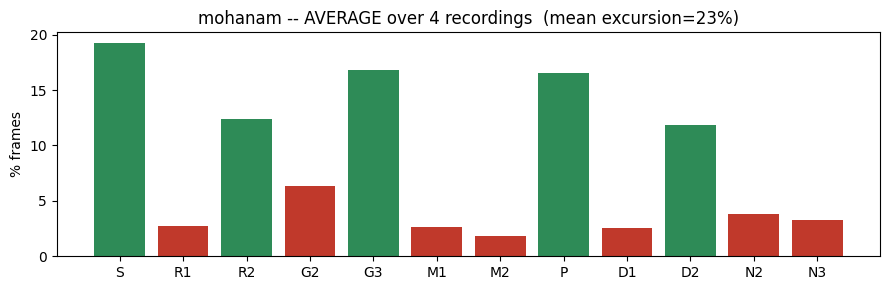

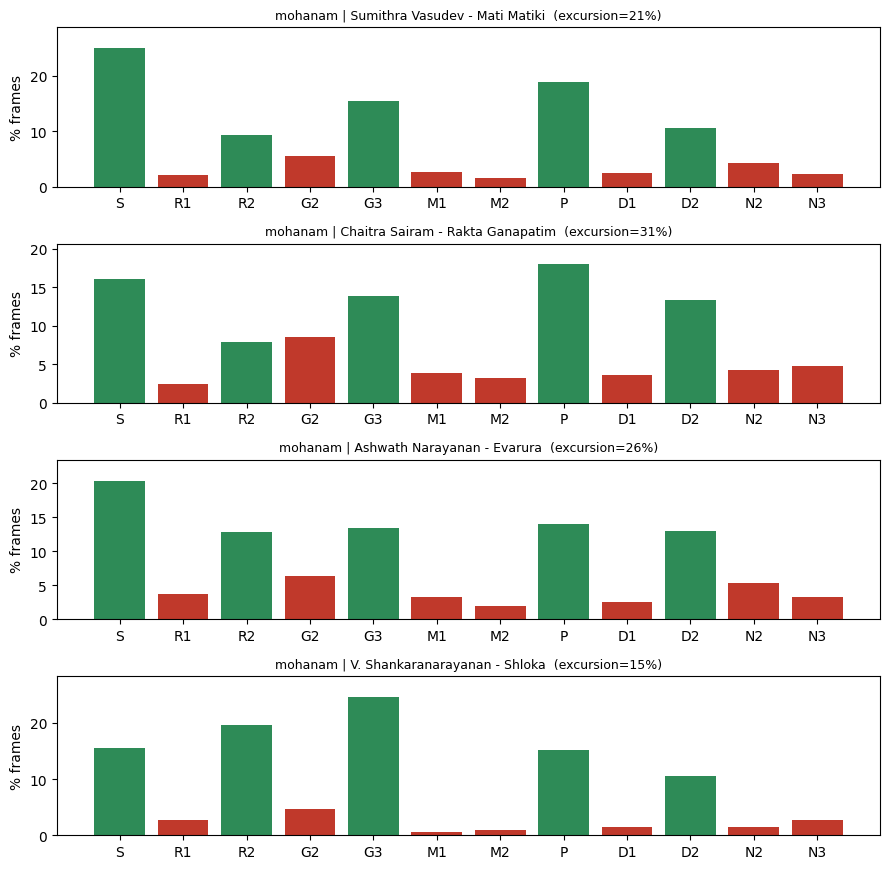

In [17]:
"""
Visualize swara histograms -- spot which notes leak, and how much.

Bars = % of voiced frames on each of the 12 swara positions.
Green bars  = swaras that belong to the raga (per RAGA_THEORY union).
Red bars    = off-scale swaras (excursion / possible tracking error).
This makes "which notes are leaking and how badly" obvious at a glance.

Run after Stage 1 v2 (needs swara_sequences.jsonl). Fill RAGA_THEORY_VIS
with the ragas you want to inspect.
"""

import json
import numpy as np
import matplotlib.pyplot as plt

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
SWARA_ORDER = ["S", "R1", "R2", "G2", "G3", "M1",
               "M2", "P", "D1", "D2", "N2", "N3"]

# swaras that BELONG to each raga (union of aro+avaro). Fill from your knowledge.
RAGA_THEORY_VIS = {
    "mohanam": {"S", "R2", "G3", "P", "D2"},          # pentatonic: no Ma, no Ni
    "behag":   {"S", "G3", "M1", "P", "N3", "R2", "D2", "M2"},  # example - verify
    # add more as you like
}


def load_by_raga(raga_name):
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if (r.get("raga") or "").lower() == raga_name.lower():
                recs.append(r)
    return recs


def plot_raga(raga_name, max_recs=6):
    recs = load_by_raga(raga_name)
    if not recs:
        print(f"No recordings found for {raga_name}")
        return
    legal = {s.upper() for s in RAGA_THEORY_VIS.get(raga_name.lower(), set())}

    n = min(len(recs), max_recs)
    fig, axes = plt.subplots(n, 1, figsize=(9, 2.2 * n), squeeze=False)
    for i in range(n):
        r = recs[i]
        hist = r["swara_hist_pct"]
        vals = [hist.get(s, 0) for s in SWARA_ORDER]
        colors = ["#2e8b57" if s in legal else "#c0392b" for s in SWARA_ORDER]
        ax = axes[i][0]
        ax.bar(SWARA_ORDER, vals, color=colors)
        off = sum(v for s, v in zip(SWARA_ORDER, vals) if s not in legal)
        ax.set_title(f"{raga_name} | {r['stem'][:45]}  "
                     f"(excursion={off:.0f}%)", fontsize=9)
        ax.set_ylabel("% frames")
        ax.set_ylim(0, max(vals) * 1.15 if vals else 1)
    plt.tight_layout()
    plt.show()


def plot_raga_average(raga_name):
    """Average histogram across all recordings of a raga -- the raga's
    'fingerprint'. Cleaner signal than any single recording."""
    recs = load_by_raga(raga_name)
    if not recs:
        print(f"No recordings for {raga_name}")
        return
    legal = {s.upper() for s in RAGA_THEORY_VIS.get(raga_name.lower(), set())}
    mat = np.array([[r["swara_hist_pct"].get(s, 0) for s in SWARA_ORDER]
                    for r in recs])
    mean = mat.mean(axis=0)
    colors = ["#2e8b57" if s in legal else "#c0392b" for s in SWARA_ORDER]
    plt.figure(figsize=(9, 3))
    plt.bar(SWARA_ORDER, mean, color=colors)
    off = sum(v for s, v in zip(SWARA_ORDER, mean) if s not in legal)
    plt.title(f"{raga_name} -- AVERAGE over {len(recs)} recordings  "
              f"(mean excursion={off:.0f}%)")
    plt.ylabel("% frames")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # inspect Mohanam -- the cleanest diagnostic (pentatonic, no Ma/Ni)
    plot_raga_average("mohanam")
    plot_raga("mohanam", max_recs=4)

In [14]:
seq_ragas = set()
with open(SEQ_PATH) as f:
    for line in f:
        r = json.loads(line)
        rk = (r.get("raga") or "").lower()
        if rk not in ("unknown","ragamalika",""): seq_ragas.add(rk)

missing = sorted(rk for rk in seq_ragas if rk not in T)
print(f"{len(missing)} Saraga ragas have NO theory match:")
for m in missing: print("  ", m)

NameError: name 'T' is not defined

Loaded theory for 95 ragas.

0 Saraga ragas still UNMATCHED (fill these into ALIASES):


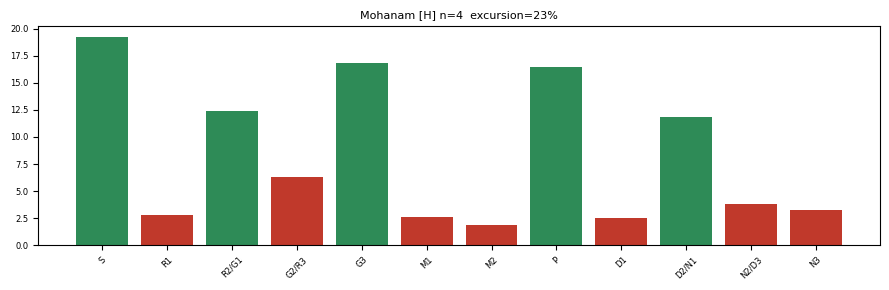

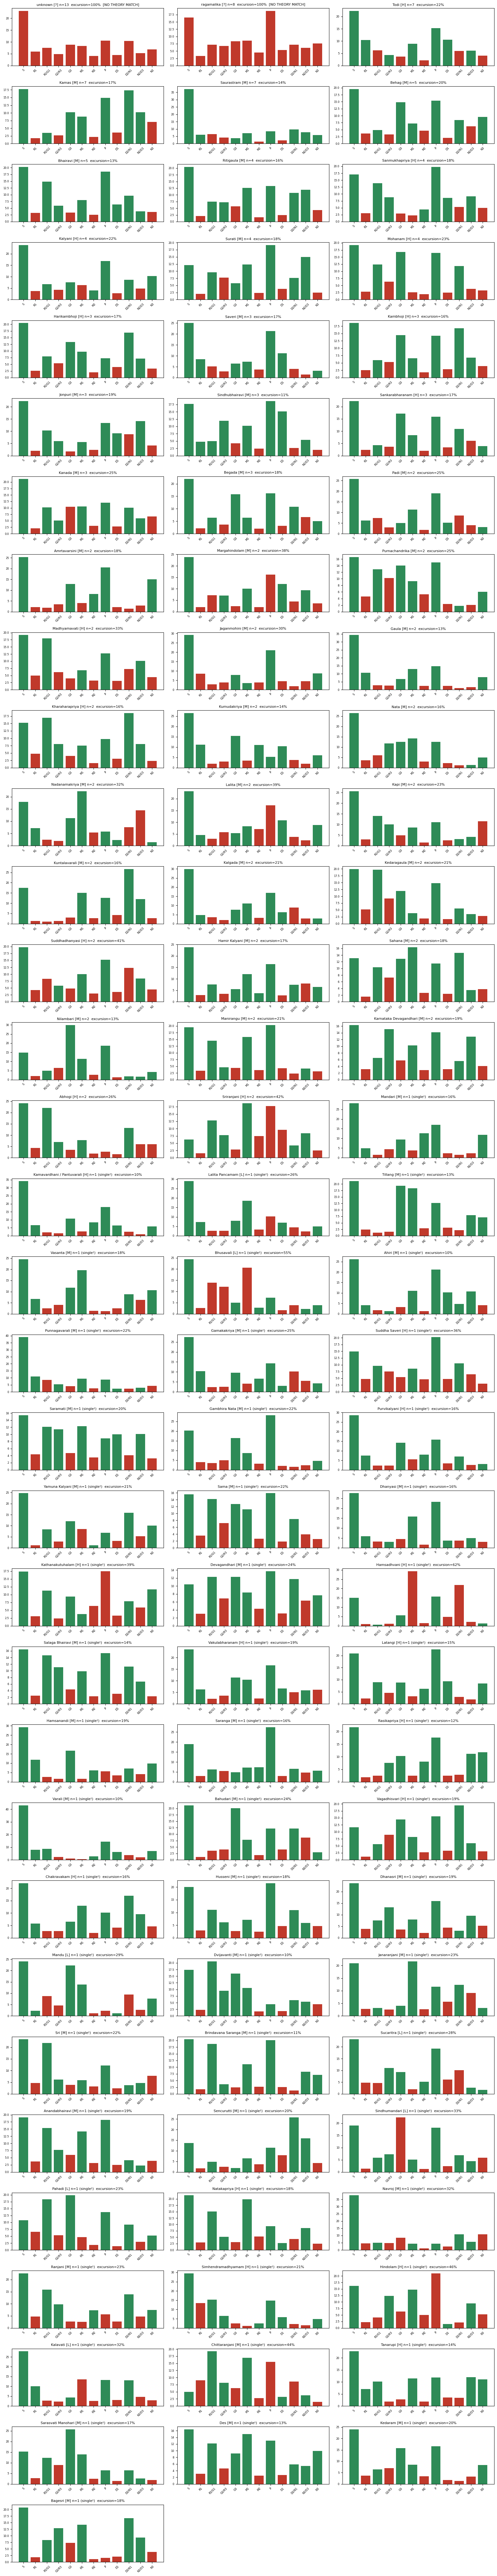

Saved grid -> /content/census_out/all_ragas_histograms.png


In [20]:
"""
COMBINED CELL (corrected): raga-theory loader + enharmonic-aware visualizer.
Paste this whole thing into ONE Colab cell and run.

Requires:
  - /content/census_out/swara_sequences.jsonl        (from Stage 1 v2)
  - /content/carnatic_ragas_arohana_avarohana.xlsx   (upload it; adjust path)
"""

import os
import re
import json
import unicodedata
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================
# PATHS
# =============================================================
XLSX_PATH = "/content/carnatic_ragas_arohana_avarohana.xlsx"
SEQ_PATH  = "/content/census_out/swara_sequences.jsonl"
assert os.path.exists(XLSX_PATH), f"Spreadsheet not found at {XLSX_PATH}"
assert os.path.exists(SEQ_PATH),  f"Sequences not found at {SEQ_PATH}"


# =============================================================
# NAME ALIASES : Saraga spelling -> spreadsheet _key() spelling
# (extend this from the 'still unmatched' printout at the bottom)
# =============================================================
ALIASES = {
    "karaharapriya":              "kharaharapriya",
    "suddadhanyasi":              "suddhadhanyasi",
    "cakravakam":                 "chakravakam",
    "simhendra madhyamam":        "simhendramadhyamam",
    "brndavana saranga":          "brindavana saranga",
    "sudda saveri":               "suddha saveri",
    "vagadisvari":                "vagadhisvari",
    "kamavardani/pantuvarali":    "kamavardhani / pantuvarali",
    "purnacandrika":              "purnachandrika",
    "cittaranjani":               "chittaranjani",
}


# =============================================================
# 12 pitch positions
# =============================================================
POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]

SYMBOL_TO_POS = {
    "S": "S", "R1": "R1",
    "R2": "R2", "G1": "R2",
    "R3": "G2", "G2": "G2",
    "G3": "G3", "M1": "M1", "M2": "M2", "P": "P", "D1": "D1",
    "D2": "D2", "N1": "D2",
    "D3": "N2", "N2": "N2",
    "N3": "N3",
}

POS12_DISPLAY = {
    "S": "S", "R1": "R1", "R2": "R2/G1", "G2": "G2/R3", "G3": "G3",
    "M1": "M1", "M2": "M2", "P": "P", "D1": "D1", "D2": "D2/N1",
    "N2": "N2/D3", "N3": "N3",
}
DISPLAY_LABELS = [POS12_DISPLAY[p] for p in POS12]


# =============================================================
# LOAD RAGA THEORY
# =============================================================
def _key(name):
    d = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", d).strip().lower()


def _parse_scale(scale_str):
    labels = []
    for tok in scale_str.split():
        t = unicodedata.normalize("NFKD", tok).encode("ascii", "ignore").decode("ascii").strip()
        if not t:
            labels.append("S")
            continue
        t = t.upper()
        if t in SYMBOL_TO_POS:
            labels.append(SYMBOL_TO_POS[t])
    return labels


def load_raga_theory(xlsx_path=XLSX_PATH):
    df = pd.read_excel(xlsx_path, sheet_name="Ragas")
    theory = {}
    for _, row in df.iterrows():
        name = str(row["Raga"]).strip()
        if not name or name.lower() == "nan":
            continue
        aro = _parse_scale(str(row["Arohana"]))
        avaro = _parse_scale(str(row["Avarohana"]))
        theory[_key(name)] = {
            "display": name, "aro": aro, "avaro": avaro,
            "all": set(aro) | set(avaro),
            "confidence": str(row.get("Confidence", "")).strip(),
            "notes": str(row.get("Notes", "")).strip(),
        }
    return theory


T = load_raga_theory()
print(f"Loaded theory for {len(T)} ragas.")


# =============================================================
# HELPERS  (alias applied BEFORE lookup in T)
# =============================================================
def theory_entry(raga_key):
    """Return the theory dict for a Saraga raga key, applying the alias map."""
    key = ALIASES.get(raga_key, raga_key)
    return T.get(key)


def _legal_positions(raga_key):
    entry = theory_entry(raga_key)
    return set(entry["all"]) if entry else set()


def load_by_raga():
    by = defaultdict(list)
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            rk = (r.get("raga") or "").lower()
            by[rk].append(r)
    return by


_BY_RAGA = load_by_raga()


# =============================================================
# PLOTTING
# =============================================================
def plot_raga_average(raga_key, ax=None):
    recs = _BY_RAGA.get(raga_key, [])
    if not recs:
        if ax is None:
            print(f"No recordings for {raga_key}")
        return
    legal = _legal_positions(raga_key)
    mat = np.array([[r["swara_hist_pct"].get(s, 0) for s in POS12] for r in recs])
    mean = mat.mean(axis=0)
    colors = ["#2e8b57" if s in legal else "#c0392b" for s in POS12]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(DISPLAY_LABELS, mean, color=colors)
    off = sum(v for s, v in zip(POS12, mean) if s not in legal)

    entry = theory_entry(raga_key) or {}
    disp = entry.get("display", raga_key)
    conf = entry.get("confidence", "?")
    matched = "" if entry else "  [NO THEORY MATCH]"
    tag = f"n={len(recs)}" + (" (single!)" if len(recs) == 1 else "")
    ax.set_title(f"{disp} [{conf}] {tag}  excursion={off:.0f}%{matched}", fontsize=8)
    ax.tick_params(labelsize=6)
    ax.tick_params(axis="x", rotation=45)
    if standalone:
        plt.tight_layout(); plt.show()


def plot_all(save_path="/content/census_out/all_ragas_histograms.png"):
    ordered = sorted(_BY_RAGA.items(), key=lambda kv: -len(kv[1]))
    cols = 3
    rows = (len(ordered) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 2.5 * rows))
    axes = axes.flatten()
    i = -1
    for i, (rk, _) in enumerate(ordered):
        plot_raga_average(rk, ax=axes[i])
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"Saved grid -> {save_path}")


# =============================================================
# DIAGNOSTIC: which Saraga ragas still have NO theory match?
# =============================================================
def report_unmatched():
    seq_ragas = {rk for rk in _BY_RAGA if rk not in ("unknown", "ragamalika", "")}
    missing = sorted(rk for rk in seq_ragas if theory_entry(rk) is None)
    print(f"\n{len(missing)} Saraga ragas still UNMATCHED "
          f"(fill these into ALIASES):")
    for m in missing:
        print(f"   '{m}': '',")
    return missing


# =============================================================
# RUN
# =============================================================
report_unmatched()               # fix names first
plot_raga_average("mohanam")     # control
plot_all()                       # full wall

# Stage 2 — Baselines: Bag-of-Notes & Swara-Transition Retrieval

## Where we are in the project

**Phase: Information Retrieval — baseline representations & first evaluation.**

This is the first stage that is genuinely **IR**. Stage 1 (feature extraction)
turned recordings into swara sequences; Stage 2 turns those sequences into
**vector representations**, defines a **similarity function**, runs **retrieval**,
and measures it with **IR metrics**. That quartet — represent, score, retrieve,
evaluate — is the core loop of information retrieval.

Pipeline position: Census → Feature Extraction → **Baselines (here)** → Language
Model → Dense Retrieval → Evaluation.

Why baselines come before the learned model: the project's central claim is that
**movement (sanchara) matters beyond the note-set**. To show a learned model
captures movement, we first need simple reference points that (a) capture only
note-content and (b) capture only first-order movement. These are the strawman and
the floor the learned model must beat. Without them, a good learned result is
unfalsifiable — you cannot claim improvement without a baseline to improve over.

---

## What Stage 2 builds

### Baseline 1 — Bag-of-Notes (the strawman)
- **Representation:** a 12-dimensional vector — the proportion of each swara
  position in a recording.
- **What it captures:** *what notes* are present, and how often.
- **What it ignores:** order, movement, gamaka — everything sequential.
- **Expected weakness:** it cannot distinguish ragas that share a scale but differ
  in movement (allied ragas). This failure is the point — it motivates everything
  after it. It is the "bag of words" of this project.

### Baseline 2 — Swara-Transition Matrix (the floor)
- **Representation:** a 12×12 first-order Markov matrix, row-normalized, flattened
  to 144 dimensions — P(next swara | current swara).
- **What it captures:** *which swara follows which* — the first computational
  shadow of sanchara.
- **Why it should beat Baseline 1:** movement carries raga identity that raw
  note-content does not. If it wins, the project's core premise is demonstrated at
  the simplest possible level, before any deep learning.
- **What it still misses:** long-range phrase structure, gamaka shape, directional
  (aroha/avaroha) asymmetry beyond immediate transitions. These are what the
  learned model (Stage 4) exists to capture.

---

## Evaluation

**Task:** same-raga retrieval (query-by-example). Each recording is a query; all
others are ranked by cosine similarity of their vectors. A retrieved recording is
**relevant** if it shares the query's raga.

**Why query-by-example:** it is the honest IR framing of "does this representation
place musically-similar recordings near each other," and it needs no training — so
it fairly evaluates the *representation itself*, not a classifier fit on top.

**Metrics:**
- **Precision@k** (k = 1, 3, 5): fraction of the top-k that are same-raga.
- **MAP** (mean average precision): rewards ranking all relevant items high.
- **MRR** (mean reciprocal rank): how high the *first* correct hit appears.

**Query eligibility:** only recordings whose raga has ≥2 recordings are used as
queries — otherwise no correct answer exists to retrieve. This automatically
excludes the singleton-raga tail and keeps the metric meaningful.

**Similarity:** cosine over L2-normalized vectors — standard for this kind of
sparse count/probability representation, and scale-invariant.

---

## What the results will tell us

1. **Absolute level.** With ~20 evaluable ragas, random P@1 is low; scores well
   above chance mean the representations carry real raga signal.
2. **The key comparison — does Baseline 2 beat Baseline 1?**
   - *If yes:* movement helps over note-content alone — core premise supported at
     baseline level. This is a genuine, reportable finding on its own.
   - *If roughly equal:* first-order transitions are insufficient; the learned
     model has clear, well-motivated work to do. Also informative.
3. **The benchmark.** Whatever these numbers are, they are the bar Stage 4's
   learned representation must clear. Improvement is defined relative to them.

---

## Honest limitations (documented, not hidden)

- **First-order only.** The transition matrix sees pairs, not phrases. Ragas
  distinguished by longer characteristic movement will still be confused.
- **Direction-blind aggregate.** A transition matrix mixes ascending and
  descending contexts; it does not separately model aroha vs avaroha the way the
  theory (and Stage 1's directional diagnostic) does.
- **No gamaka shape.** The per-note gamaka descriptors from Stage 1 are not yet
  used here; these baselines operate on the collapsed symbolic sequence only.
- **Small data.** Absolute metric values are on a modest collection; trends and
  relative comparisons are more trustworthy than any single number.

These limitations are not flaws to apologize for — each one names a specific thing
the learned model is designed to address, so Stage 2 also functions as the
motivation for Stage 4.

---

## Output

- `stage2_baseline_results.csv` — the metrics table for both representations.
- Serves as the benchmark row(s) that all later results are compared against.

---

## Next

**Stage 3 (optional refinement) / Stage 4 (the learned model).** Depending on the
baseline gap: if first-order transitions already help meaningfully, proceed to the
self-supervised swara language model, whose learned representation should capture
the longer-range and directional structure these baselines cannot. The baseline
table defines exactly what "better" has to mean.

In [21]:
"""
Stage 2 -- Baselines: bag-of-notes & swara-transition retrieval
=============================================================
Builds the two DELIBERATELY-SIMPLE representations the learned model (Stage 4)
must beat, and runs the first real IR evaluation on them.

  Baseline 1  BAG-OF-NOTES  (swara-presence vector)
              12-d: how much of each swara a recording contains.
              Captures WHAT notes, not MOVEMENT. Confuses allied ragas. Strawman.

  Baseline 2  TRANSITION MATRIX  (first-order Markov)
              12x12 -> 144-d flattened: P(next swara | current swara).
              Captures MOVEMENT (which swara follows which) -> encodes early
              sanchara. The "floor" the learned model must exceed.

EVALUATION: same-raga retrieval (query-by-example).
  For each recording, rank all others by similarity; check whether same-raga
  recordings come back on top. Metrics: Precision@k, MAP, MRR.

  Split note: for a fair test we evaluate on the well-populated ragas only, and
  report per-raga so single-recording ragas (no same-raga target) are excluded.

Requires: swara_sequences.jsonl (Stage 1 v2).
-------------------------------------------------------------
"""

import os
import json
from collections import defaultdict

import numpy as np
import pandas as pd

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
IDX = {s: i for i, s in enumerate(POS12)}
SIL = "_"


# =============================================================
# LOAD
# =============================================================
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and (r["raga"].lower() not in ("unknown", "ragamalika")):
                recs.append(r)
    return recs


# =============================================================
# REPRESENTATIONS
# =============================================================
def bag_of_notes(seq):
    """12-d normalized count of swaras (silence ignored)."""
    v = np.zeros(12)
    for s in seq:
        if s in IDX:
            v[IDX[s]] += 1
    tot = v.sum()
    return v / tot if tot > 0 else v


def transition_matrix(seq):
    """12x12 row-normalized first-order transition probs, flattened to 144-d.
    Silence breaks continuity (no transition across a phrase boundary)."""
    M = np.zeros((12, 12))
    prev = None
    for s in seq:
        if s == SIL or s not in IDX:
            prev = None
            continue
        cur = IDX[s]
        if prev is not None:
            M[prev, cur] += 1
        prev = cur
    # row-normalize
    rowsum = M.sum(axis=1, keepdims=True)
    rowsum[rowsum == 0] = 1
    M = M / rowsum
    return M.flatten()


def build_representations(recs):
    bon = np.array([bag_of_notes(r["collapsed_seq"]) for r in recs])
    trans = np.array([transition_matrix(r["collapsed_seq"]) for r in recs])
    ragas = [r["raga"].lower() for r in recs]
    artists = [r.get("artist", "UNKNOWN") for r in recs]
    return bon, trans, ragas, artists


# =============================================================
# RETRIEVAL EVAL
# =============================================================
def cosine_sim_matrix(X):
    norm = np.linalg.norm(X, axis=1, keepdims=True)
    norm[norm == 0] = 1
    Xn = X / norm
    return Xn @ Xn.T


def evaluate(X, ragas, name, ks=(1, 3, 5)):
    """Query-by-example: each recording queries the rest, ranked by cosine.
    Relevant = same raga. Only queries whose raga has >=2 recordings count
    (otherwise there is no correct answer to retrieve)."""
    sim = cosine_sim_matrix(X)
    n = len(ragas)
    raga_counts = defaultdict(int)
    for r in ragas:
        raga_counts[r] += 1

    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0

    for i in range(n):
        if raga_counts[ragas[i]] < 2:
            continue  # no same-raga target exists
        evaluable += 1
        order = np.argsort(-sim[i])
        order = order[order != i]  # drop self
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)

        for k in ks:
            precisions[k].append(rel[:k].sum() / k)

        # average precision
        if rel.sum() > 0:
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            # reciprocal rank
            first = np.argmax(rel) + 1
            rrs.append(1.0 / first)

    row = {"representation": name, "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(np.mean(precisions[k]), 3)
    row["MAP"] = round(np.mean(aps), 3)
    row["MRR"] = round(np.mean(rrs), 3)
    return row


# =============================================================
# MAIN
# =============================================================
def main():
    recs = load_records()
    print(f"Loaded {len(recs)} labelled recordings "
          f"({len(set(r['raga'].lower() for r in recs))} ragas).")

    bon, trans, ragas, artists = build_representations(recs)

    results = [
        evaluate(bon,   ragas, "bag_of_notes (strawman)"),
        evaluate(trans, ragas, "transition_matrix (floor)"),
    ]
    df = pd.DataFrame(results)
    print("\n=== Same-raga retrieval (higher = better) ===")
    print(df.to_string(index=False))
    df.to_csv(os.path.join(OUT_DIR, "stage2_baseline_results.csv"), index=False)
    print(f"\nSaved -> {os.path.join(OUT_DIR, 'stage2_baseline_results.csv')}")

    print("\nInterpretation:")
    print("- If transition_matrix beats bag_of_notes, MOVEMENT already helps over")
    print("  note-content alone -- the core premise, shown at baseline level.")
    print("- These are the numbers the learned model (Stage 4) must exceed.")


if __name__ == "__main__":
    main()

Loaded 176 labelled recordings (95 ragas).

=== Same-raga retrieval (higher = better) ===
           representation  evaluable_queries   P@1  P@3   P@5   MAP   MRR
  bag_of_notes (strawman)                123 0.423 0.29 0.233 0.423 0.519
transition_matrix (floor)                123 0.431 0.32 0.237 0.418 0.547

Saved -> /content/census_out/stage2_baseline_results.csv

Interpretation:
- If transition_matrix beats bag_of_notes, MOVEMENT already helps over
  note-content alone -- the core premise, shown at baseline level.
- These are the numbers the learned model (Stage 4) must exceed.


# Results — Interpretation & Implications

## The numbers

| Representation | Eval queries | P@1 | P@3 | P@5 | MAP | MRR |
|---|---|---|---|---|---|---|
| Bag-of-notes (strawman) | 123 | 0.423 | 0.290 | 0.233 | **0.423** | 0.519 |
| Transition matrix (floor) | 123 | **0.431** | **0.320** | **0.237** | 0.418 | **0.547** |

176 labelled recordings across 95 ragas; 123 queries evaluable (raga has ≥2 recordings).

---

## What the results mean

### 1. Both representations carry real raga signal
With 95 ragas in the collection, chance-level P@1 is on the order of 1–5%.
Both representations achieve **~42% P@1** — the single nearest neighbour is the
same raga more than 40% of the time. So the swara sequences produced in Stage 1
are musically meaningful: raga identity survives the pitch→swara extraction. This
validates the feature-extraction pipeline from a retrieval standpoint, not just by
eye.

### 2. The two baselines are effectively tied
Transition matrix edges bag-of-notes on P@1, P@3, P@5, and MRR, but loses on MAP,
and **every margin is 1–3 points** — within noise for 123 queries. The honest
reading is **not** "movement beats note-content." It is: **first-order movement and
raw note-content perform about the same at the aggregate level.**

We deliberately do not overclaim the transition win. The gaps are too small to
support the thesis on their own.

### 3. Why the tie is expected — and why it *motivates* the project
A 12×12 transition matrix aggregated over a whole recording is still a coarse view
of movement. It discards exactly the things that carry raga identity:
- **Direction** — it mixes ascending and descending contexts into one matrix, so
  aroha/avaroha asymmetry (Bilahari-type ragas) is invisible.
- **Phrase length** — sancara are multi-note gestures; first-order transitions see
  only adjacent pairs.
- **Gamaka shape** — the oscillation profiles captured in Stage 1 are not used
  here.

Moreover, most of the 95 ragas have **distinct note-sets**, so bag-of-notes already
separates them — and where note-content alone suffices, movement adds nothing. The
place movement *should* matter is the minority of **allied ragas** (same scale,
different movement), and their effect is **diluted** in an average taken over all
ragas.

**Conclusion:** the aggregate tie is evidence for a precise claim — *shallow,
direction-blind, aggregated movement is not enough*. That is the strongest possible
motivation for a sequence model (Stage 4) that captures direction, longer phrases,
and context.

---

## How this affects the study

1. **The evaluation must be sharpened.** The aggregate metric hides the effect that
   matters. The next step (Stage 3) restricts evaluation to **allied / same-scale
   confusions**, where movement should separate what note-content cannot. If the
   transition matrix beats bag-of-notes *there*, the premise is supported on the
   cases that actually test it — a far stronger result than the aggregate.

2. **The benchmark is set.** Stage 4's learned model must (a) exceed ~0.42 P@1
   overall, and — more importantly — (b) separate allied-raga clusters that the
   baselines conflate. "Better" is now concretely defined.

3. **A negative-to-precise reframing.** "The baselines tied" is not a dead end; it
   converts into "here are the exact confusions shallow methods cannot resolve,"
   which is a sharper and more publishable framing than a raw accuracy number.

4. **Reporting integrity.** Carrying the honest tie (rather than spinning the
   1-point transition win) is itself a strength — it demonstrates evaluation rigor,
   which is exactly what an MIR-evaluation audience (e.g. ISMIR reviewers) rewards.

---

## One-line summary

The baselines prove the sequences carry raga signal but show that **crude movement
≈ note-content on average** — so the real question is whether movement helps **on
allied ragas specifically**, which is what Stage 3 isolates and Stage 4 is built to
exploit.

Stage 3

In [1]:
"""
Stage 3 -- Confusion analysis: where does movement beat note-content?
=============================================================
Stage 2 showed bag-of-notes and transition-matrix tie ON AVERAGE. That average is
dominated by ragas with distinct note-sets, where note-content already suffices.
The premise of the project -- movement (sanchara) carries identity beyond notes --
should show up specifically on ALLIED ragas (same/similar scale, different
movement). This stage isolates those cases.

Three analyses:
  (A) Confusion pairs: which ragas get retrieved for which? Surfaces the ragas
      each representation actually confuses.
  (B) Scale-overlap stratification: split raga PAIRS by how much their note-sets
      overlap (Jaccard). Compare bag-of-notes vs transition ON HIGH-OVERLAP pairs
      (the allied cases) vs low-overlap pairs. Movement should help more on high
      overlap.
  (C) Same-melakarta / same-scale clusters: retrieval error rate within known
      allied clusters, per representation.

Requires: swara_sequences.jsonl, and the raga theory loader (for scale overlap).
Uses the SAME representations as Stage 2 (imported/redefined here).
-------------------------------------------------------------
"""

import os
import re
import json
import unicodedata
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
XLSX_PATH = "/content/carnatic_ragas_arohana_avarohana.xlsx"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
IDX = {s: i for i, s in enumerate(POS12)}
SIL = "_"

# reuse the alias map from the visualizer (extend if needed)
ALIASES = {
    "karaharapriya":              "kharaharapriya",
    "suddadhanyasi":              "suddhadhanyasi",
    "cakravakam":                 "chakravakam",
    "simhendra madhyamam":        "simhendramadhyamam",
    "brndavana saranga":          "brindavana saranga",
    "sudda saveri":               "suddha saveri",
    "vagadisvari":                "vagadhisvari",
    "kamavardani/pantuvarali":    "kamavardhani / pantuvarali",
    "purnacandrika":              "purnachandrika",
    "cittaranjani":               "chittaranjani",
}

SYMBOL_TO_POS = {
    "S": "S", "R1": "R1", "R2": "R2", "G1": "R2", "R3": "G2", "G2": "G2",
    "G3": "G3", "M1": "M1", "M2": "M2", "P": "P", "D1": "D1", "D2": "D2",
    "N1": "D2", "D3": "N2", "N2": "N2", "N3": "N3",
}


# ---------- theory (for scale overlap) ----------
def _key(name):
    d = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", d).strip().lower()


def _parse_scale(s):
    out = []
    for tok in str(s).split():
        t = unicodedata.normalize("NFKD", tok).encode("ascii", "ignore").decode("ascii").strip().upper()
        if not t:
            out.append("S")
        elif t in SYMBOL_TO_POS:
            out.append(SYMBOL_TO_POS[t])
    return out


def load_theory():
    df = pd.read_excel(XLSX_PATH, sheet_name="Ragas")
    T = {}
    for _, row in df.iterrows():
        name = str(row["Raga"]).strip()
        if not name or name.lower() == "nan":
            continue
        allsw = set(_parse_scale(row["Arohana"])) | set(_parse_scale(row["Avarohana"]))
        T[_key(name)] = allsw
    return T


T = load_theory()


def scale_set(raga_key):
    return T.get(ALIASES.get(raga_key, raga_key), set())


# ---------- representations (same as Stage 2) ----------
def bag_of_notes(seq):
    v = np.zeros(12)
    for s in seq:
        if s in IDX:
            v[IDX[s]] += 1
    tot = v.sum()
    return v / tot if tot else v


def transition_matrix(seq):
    M = np.zeros((12, 12))
    prev = None
    for s in seq:
        if s == SIL or s not in IDX:
            prev = None
            continue
        c = IDX[s]
        if prev is not None:
            M[prev, c] += 1
        prev = c
    rs = M.sum(1, keepdims=True); rs[rs == 0] = 1
    return (M / rs).flatten()


def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def cos(X):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    Xn = X / n
    return Xn @ Xn.T


# =============================================================
# (A) CONFUSION PAIRS
# =============================================================
def confusion_pairs(X, ragas, name, top=15):
    sim = cos(X)
    n = len(ragas)
    counts = Counter(ragas)
    confusions = Counter()
    for i in range(n):
        if counts[ragas[i]] < 2:
            continue
        order = np.argsort(-sim[i])
        order = order[order != i]
        top1 = ragas[order[0]]
        if top1 != ragas[i]:
            pair = tuple(sorted([ragas[i], top1]))
            confusions[pair] += 1
    print(f"\n[{name}] most frequent top-1 CONFUSIONS (retrieved wrong raga):")
    for (a, b), c in confusions.most_common(top):
        j = len(scale_set(a) & scale_set(b))
        u = len(scale_set(a) | scale_set(b)) or 1
        print(f"   {a:22s} <-> {b:22s}  x{c}   scale_overlap={j/u:.2f}")
    return confusions


# =============================================================
# (B) STRATIFY BY SCALE OVERLAP
# =============================================================
def stratified_by_overlap(bon, trans, ragas):
    """For each query, does the top-1 share the query's raga? Bucket queries by
    whether the *confusing* raga (top-1 if wrong) has high scale overlap. Compare
    the two representations on high- vs low-overlap difficulty."""
    def per_rep(X):
        sim = cos(X)
        counts = Counter(ragas)
        # bucket: for wrong top-1s, is the wrong raga high-overlap (allied) or not
        hi_correct = hi_total = lo_correct = lo_total = 0
        for i in range(len(ragas)):
            if counts[ragas[i]] < 2:
                continue
            order = np.argsort(-sim[i]); order = order[order != i]
            top1 = ragas[order[0]]
            correct = int(top1 == ragas[i])
            # difficulty proxy: max scale-overlap this raga has with ANY other raga
            # (allied ragas live in high-overlap neighbourhoods)
            ov = max((len(scale_set(ragas[i]) & scale_set(r)) /
                      (len(scale_set(ragas[i]) | scale_set(r)) or 1))
                     for r in set(ragas) if r != ragas[i])
            if ov >= 0.8:
                hi_total += 1; hi_correct += correct
            else:
                lo_total += 1; lo_correct += correct
        hi = hi_correct / hi_total if hi_total else float("nan")
        lo = lo_correct / lo_total if lo_total else float("nan")
        return hi, lo, hi_total, lo_total

    b_hi, b_lo, hn, ln = per_rep(bon)
    t_hi, t_lo, _, _ = per_rep(trans)
    print("\n=== P@1 stratified by scale-overlap neighbourhood ===")
    print(f"(high-overlap = ragas that share >=80% of notes with some other raga; "
          f"n_hi={hn}, n_lo={ln})")
    df = pd.DataFrame([
        {"representation": "bag_of_notes",      "P@1_high_overlap": round(b_hi, 3), "P@1_low_overlap": round(b_lo, 3)},
        {"representation": "transition_matrix", "P@1_high_overlap": round(t_hi, 3), "P@1_low_overlap": round(t_lo, 3)},
    ])
    print(df.to_string(index=False))
    print("\nKey question: does transition_matrix beat bag_of_notes in the "
          "HIGH-overlap column? That is where movement should matter.")
    df.to_csv(os.path.join(OUT_DIR, "stage3_overlap_stratified.csv"), index=False)
    return df


# =============================================================
# MAIN
# =============================================================
def main():
    recs = load_records()
    ragas = [r["raga"].lower() for r in recs]
    bon = np.array([bag_of_notes(r["collapsed_seq"]) for r in recs])
    trans = np.array([transition_matrix(r["collapsed_seq"]) for r in recs])

    print(f"Loaded {len(recs)} recordings, {len(set(ragas))} ragas.")

    # (A) what gets confused
    confusion_pairs(bon,   ragas, "bag_of_notes")
    confusion_pairs(trans, ragas, "transition_matrix")

    # (B) does movement help specifically on high-overlap (allied) ragas?
    stratified_by_overlap(bon, trans, ragas)

    print("\nInterpretation:")
    print("- If the SAME allied pairs are confused by bag_of_notes but NOT by")
    print("  transition_matrix, that is direct evidence movement separates them.")
    print("- If transition_matrix's P@1 advantage concentrates in the HIGH-overlap")
    print("  column, the aggregate tie was hiding a real effect on allied ragas.")


if __name__ == "__main__":
    main()

FileNotFoundError: [Errno 2] No such file or directory: '/content/carnatic_ragas_arohana_avarohana.xlsx'